# Tutorial 9: GID pattern simulation

This tutorial uses the `pygidSIM` package to simulate GIWAXS patterns based on a **CIF file** describing the crystal structure.
The function `make_simulation()` overlays simulated diffraction peaks onto the experimental GIWAXS image.

Before starting, download the required datasets from **Zenodo** (or provide your own data files) and create an `analysis` instance as described in **Tutorial 3**.


In [3]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
files = get_dataset("tutorial_09")
data_path = files["data_peaks"]
poni_path = files["poni_peaks"]
mask_path = files["mask_peaks"]
cif_path_peaks = files["cif_peaks"]

In [4]:
import pygid

# create pygid.ExpParams based on the PONI file
params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    mask_path=mask_path,
    ai=0.01,                       # angle of incidence (degrees)
    fliplr=True,
    flipud=True
)

# create pygid.CoordMaps based on pygid.ExpParams
matrix = pygid.CoordMaps(
    params,  # pygid.ExpParams
    hor_positive=True,
    vert_positive=True
)

# load the data from file
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
    dataset='/entry_0000/ESRF-ID10/eiger4m/data',  # dataset path
    frame_num=7
)

## Parameters

- `frame_num` – frame number of the experimental data to plot.
- `path_to_cif` – path to the `.cif` file defining the crystal structure. Can also be provided as a list for multiple simulations.
- `orientation` – crystal orientation in the laboratory frame specified as `[u, v, w]`; set to `None` for random orientation. Can also be provided as a list for multiple simulations.

---

## Minimal code example


INFO - Simulating GIWAXS data: path_to_cif='C:\Users\Ainur Abukaev\.cache\pygid\tutorial_09\DIP_thin_film_642482.cif', orientation=[0, 0, 1], min_int=0.001


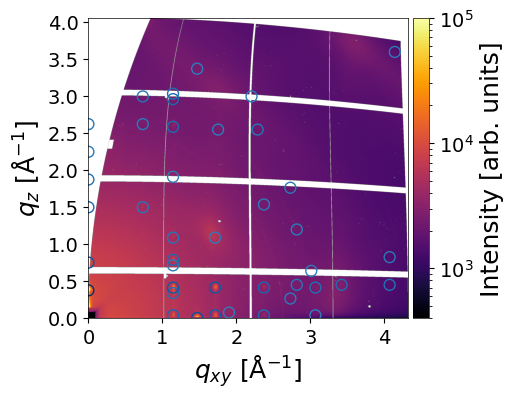

INFO - frame_num = 0 was plotted


In [5]:
analysis.make_simulation(
    frame_num=0,                  # Frame of experimental data
    path_to_cif=cif_path_peaks,   # Path to crystal structure CIF
    orientation=[0, 0, 1],        # Crystal orientation in lab frame
    min_int=1e-3,                 # Minimal intensity of the peak to show
    plot_result=True,             # Display simulation overlay
    clims=(4e2,1e5),              # Intensity limits
)

---
## Plotting parameters

- `plot_result` – if `True`, displays the overlay of simulated peaks on the experimental data.
- `cmap` – matplotlib colormap for the simulated diffraction peaks. Can also be provided as a list for multiple simulations.
- `clims` – tuple `(vmin, vmax)` specifying the intensity limits of the experimental image.
- `min_int` – minimum intensity threshold for displaying simulated reflections. Can also be provided as a list for multiple simulations.
- `vmin`, `vmax` – normalization range for color scaling of simulated peaks.
- `linewidth` – line width of the simulated diffraction peaks.
- `radius` – radius of the simulated peaks in display units.
- `plot_mi` – if `True`, annotates simulated peaks with Miller indices (hkl).

## Other parameters

- `return_result` – if `True`, returns a simulation result object.
- `save_fig` – if `True`, saves the resulting image.
- `path_to_save_fig` – filename for saving the image.
- `move_fromMW` – if `True`, moves reflections from the missing wedge to the border.

---

## Single simulation example
### Oriented crystal

INFO - Simulating GIWAXS data: path_to_cif='C:\Users\Ainur Abukaev\.cache\pygid\tutorial_09\DIP_thin_film_642482.cif', orientation=[0, 0, 1], min_int=0.001


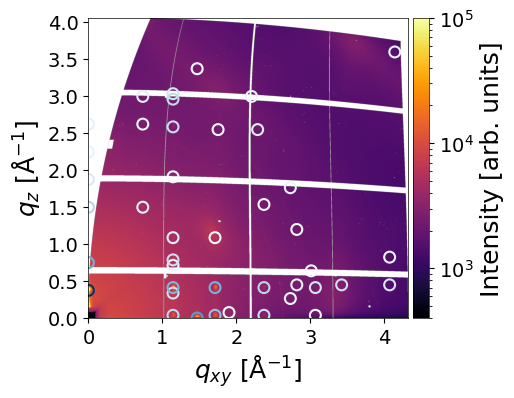

INFO - frame_num = 0 was plotted


In [6]:
q_values, intensity, mi = analysis.make_simulation(
    frame_num=0,                  # Frame of experimental data
    clims=(4e2,1e5),              # Color scale limits for experimental image
    path_to_cif=cif_path_peaks,         # Path to crystal structure CIF
    orientation=[0, 0, 1],        # Crystal orientation in lab frame
    min_int=1e-3,                 # Minimum intensity for reflections
    plot_result=True,             # Display simulation overlay
    cmap='Blues',                 # Colormap for simulated peaks
    vmin=1e-3, vmax=1,             # Color normalization range
    linewidth=1.5,                # Line width of peaks
    radius=0.1,                   # Peak radius
    plot_mi=False,                # Annotate peaks with Miller indices
    return_result=True,           # Return simulation result
)

The simulated peaks are visualized as circles, with colors proportional to their intensity. The color scale can be controlled using the `vmin` and `vmax` parameters, and the size of the circles can be adjusted with the `radius` parameter. When `return_result=True`, the function returns:

- `q_values` – a 2D array of peak positions (`q_xy`, `q_z`) (in Å⁻¹)
- `intensity` – array of simulated peak intensities
- `mi` – corresponding Miller indices for each peak

In [7]:
# results shape
q_values.shape, intensity.shape, mi.shape

((2, 42), (42,), (42, 3))

In [8]:
# split the q_values
q_xy = q_values[0]
q_z = q_values[1]

Peaks located in the missing wedge can be moved to the border by setting the `move_fromMW=True` flag:

INFO - Simulating GIWAXS data: path_to_cif='C:\Users\Ainur Abukaev\.cache\pygid\tutorial_09\DIP_thin_film_642482.cif', orientation=[0, 0, 1], min_int=0.001


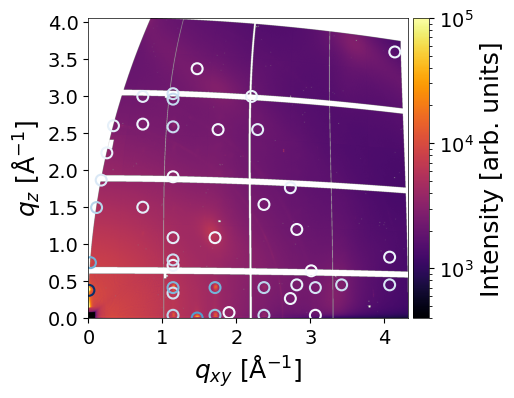

INFO - frame_num = 0 was plotted


In [9]:
q_values, intensity, mi = analysis.make_simulation(
    frame_num=0,                  # Frame of experimental data
    clims=(4e2,1e5),              # Color scale limits for experimental image
    path_to_cif=cif_path_peaks,   # Path to crystal structure CIF
    move_fromMW = True,           # Move peaks from the missing wedge
    orientation=[0, 0, 1],        # Crystal orientation in lab frame
    min_int=1e-3,                 # Minimum intensity for reflections
    plot_result=True,             # Display simulation overlay
    cmap='Blues',                 # Colormap for simulated peaks
    vmin=1e-3, vmax=1,             # Color normalization range
    linewidth=1.5,                # Line width of peaks
    radius=0.1,                   # Peak radius
    plot_mi=False,                # Annotate peaks with Miller indices
    return_result=True,           # Return simulation result
)

### Random orientation

The `make_simulation()` function can also simulate and plot diffraction rings for randomly oriented crystals. To enable this, set `orientation` to `"random"` or `None`. The sharpness of the plotted rings can be controlled using the `linewidth` parameter.

When `return_result=True`, the function returns:

- `q_values` – a 1D array of absolute q-values (`q_abs`) (in Å⁻¹)
- `intensity` – array of simulated peak intensities
- `mi` – corresponding Miller indices for each peak


In [10]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
files = get_dataset("tutorial_09")
data_path = files["data_rings"]
poni_path = files["poni_rings"]
cif_path_rings = files["cif_rings"]

In [11]:
import pygid

# create pygid.ExpParams based on the PONI file
params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    ai=0.01,                       # angle of incidence (degrees)
    fliplr=False,
    flipud=True
)

# create pygid.CoordMaps based on pygid.ExpParams
matrix = pygid.CoordMaps(
    params,  # pygid.ExpParams
    hor_positive=True,
    vert_positive=True
)

# load the data from file
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
)

INFO - Simulating GIWAXS data: path_to_cif='C:\Users\Ainur Abukaev\.cache\pygid\tutorial_09\MAPBTI02 - stoumpos_cubicMAPbI3.cif', orientation=None, min_int=1e-05


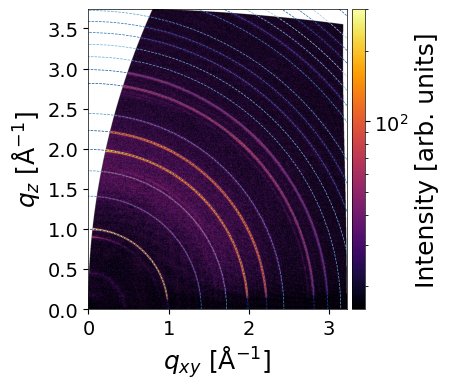

INFO - frame_num = 0 was plotted


In [12]:
q_values, intensity, mi = analysis.make_simulation(
    frame_num=0,                  # Frame of experimental data
    clims=(16,300),              # Color scale limits for experimental image
    path_to_cif=cif_path_rings,         # Path to crystal structure CIF
    orientation=None,       # Crystal orientation in lab frame
    min_int=1e-5,                 # Minimum intensity for reflections
    plot_result=True,             # Display simulation overlay
    cmap='Blues',                 # Colormap for simulated peaks
    vmin=1e-3, vmax=1,             # Color normalization range
    linewidth=0.5,                # Line width of peaks
    radius=0.1,                   # Peak radius
    plot_mi=False,                # Annotate peaks with Miller indices
    return_result=True,           # Return simulation result
)

The rings and arcs observed at 0.45, 0.51, and 0.65 Å⁻¹ are not simulated, as they originate from a Pb₃I₈ intermediate complex.


## Multiple Simulations

To plot multiple simulated patterns from different CIF files or orientations, `make_simulation()` accepts **lists** for the following parameters:

- `path_to_cif` – list of CIF file paths
- `orientation` – list of crystal orientations
- `min_int` – list of minimum intensity thresholds for reflections
- `cmap` – list of colormaps for simulated peaks

**Behavior:**
- If the numbers of elements in `path_to_cif` and `orientation` are equal, they will be **paired** and used sequentially for the simulations.
- Lists of `min_int` and `cmap` will be applied correspondingly to each simulation.


INFO - Simulating GIWAXS data: path_to_cif='C:\Users\Ainur Abukaev\.cache\pygid\tutorial_09\MAPBTI02 - stoumpos_cubicMAPbI3.cif', orientation=None, min_int=1e-05
INFO - Simulating GIWAXS data: path_to_cif='C:\Users\Ainur Abukaev\.cache\pygid\tutorial_09\DIP_thin_film_642482.cif', orientation=[0, 0, 1], min_int=0.001


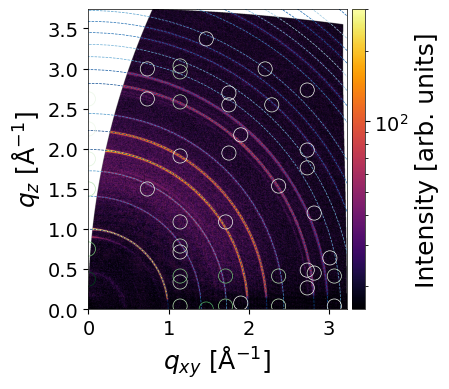

INFO - frame_num = 0 was plotted


In [17]:
result_list = analysis.make_simulation(
    frame_num=0,
    clims=(16,300),
    path_to_cif=[cif_path_rings, cif_path_peaks],         # List of CIFs
    orientation=[None, [0,0,1]],                          # List of orientations
    min_int=[1e-5, 1e-3],                                 # List of minimal intensities
    plot_result=True,
    cmap=['Blues', 'Greens'],                             # List of colormaps
    vmin=1e-3, vmax=1,
    linewidth=0.5,
    radius=0.1,
    plot_mi=False,
    return_result=True,
)

`result_list` is a list of tuples: `q_values, intensity, mi`:

In [19]:
len(result_list)

2